## Instalación de Dependencias
En este paso instalamos todas las librerías necesarias para el proyecto:
* **LangChain & LangGraph:** Para la orquestación del agente y el flujo de trabajo.
* **Groq:** Para acceder al modelo de lenguaje Llama 3 de forma rápida.
* **Ultralytics:** Para utilizar el modelo de visión YOLO (You Only Look Once).

In [1]:
# Instalación de librerías necesarias
!pip install -q -U langchain-groq langchain-community langgraph ultralytics langchain_core

## Importación y Configuración del Entorno
Aquí importamos las herramientas necesarias y configuramos la seguridad.
* Se gestionan las claves API (API Key) de Groq para que el agente pueda "hablar".
* Se cargan las librerías para manipular imágenes y archivos en Google Colab.

In [2]:
import os
import getpass
import warnings
from collections import Counter

from google.colab import userdata, files
from IPython.display import Image, display

from ultralytics import YOLO
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent

# Configuración de la API Key de Groq
try:
    os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')
    print("API Key cargada desde los secretos de Colab.")
except Exception:
    print("No se encontró el secreto 'GROQ_API_KEY'.")
    if "GROQ_API_KEY" not in os.environ:
        os.environ["GROQ_API_KEY"] = getpass.getpass("Introduce tu Groq API Key manualmente: ")

API Key cargada desde los secretos de Colab.


## Carga del Modelo YOLO
En este paso inicializamos el modelo de visión artificial:
* Cargamos los pesos del modelo **YOLOv8n** (la 'n' significa *nano*).
* Elegimos la versión *nano* porque es la más ligera y rápida, ideal para ejecutarse en entornos como Google Colab sin consumir demasiados recursos, manteniendo una buena precisión para detectar objetos comunes (personas, coches, animales, etc.).

In [3]:
# Inicializamos el modelo YOLO

yolo_model = YOLO('yolov8n.pt')
print("Modelo YOLO cargado y listo")

Modelo YOLO cargado y listo


## Definición de la Herramienta de Visión
Creamos una herramienta personalizada llamada `detectar_objetos` decorada con `@tool`.
* Esta función actúa como los "ojos" del agente.
* Utiliza YOLO para escanear la imagen y devuelve un **resumen de texto** (ej: "hay 2 personas y 1 autobús") para que el modelo de lenguaje (LLM) pueda entender qué hay en la foto sin verla directamente.

In [4]:
@tool
def detectar_objetos(ruta_imagen: str) -> str:
    """
    Utiliza esta herramienta para detectar qué objetos, animales o personas hay en una imagen.
    Entrada: La ruta del archivo de la imagen (ej: 'imagen.jpg').
    Salida: Un resumen de texto con los objetos detectados y su cantidad.
    """
    try:
        # Ejecutamos la inferencia con YOLO
        # conf=0.5 filtra detecciones con menos del 50% de certeza para mayor precisión
        resultados = yolo_model(ruta_imagen, conf=0.5, verbose=False)

        # Procesamos los resultados
        objetos_encontrados = []

        # Tomamos el primer resultado (solo hay una imagen)
        result = resultados[0]

        if not result.boxes:
            return "No se han detectado objetos reconocibles en la imagen"

        # Extraemos los nombres de las clases detectadas
        for box in result.boxes:
            cls_id = int(box.cls[0])
            nombre_clase = result.names[cls_id]
            objetos_encontrados.append(nombre_clase)

        # Contamos los objetos (ej: {'person': 2, 'dog': 1})
        conteo = Counter(objetos_encontrados)

        # Formateamos la respuesta para el agente
        descripcion = "En la imagen se han detectado: " + ", ".join([f"{cant} {obj}" for obj, cant in conteo.items()])
        return descripcion

    except Exception as e:
        return f"Error al procesar la imagen: {str(e)}"

# Lista de herramientas para el agente
tools = [detectar_objetos]

## Inicialización del Agente
Configuramos el "cerebro" de la aplicación:
* Instanciamos el modelo **Llama-3** a través de Groq.
* Creamos el agente ReAct usando `create_react_agent`, vinculándolo con nuestra herramienta de visión. Esto permite al agente decidir cuándo necesita "mirar" la imagen para responder al usuario.

In [5]:
# Suprimimos los warnings de versiones para mantener la salida limpia
warnings.filterwarnings("ignore")

# Inicializamos el LLM con Groq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

# Creamos el agente ReAct
# Este agente sabrá automáticamente cuándo llamar a 'detectar_objetos'
agent_executor = create_react_agent(llm, tools)

print("Agente creado exitosamente")

Agente creado exitosamente


## Lógica Principal y Visualización
Esta es la función `main` que orquesta todo el flujo:
1.  **Subida:** Solicita al usuario que suba una imagen.
2.  **Consulta:** Envía la imagen y la pregunta al Agente (que usará la herramienta de visión si lo necesita).
3.  **Respuesta:** Muestra la explicación textual del agente.
4.  **Visualización:** Como paso final, vuelve a procesar la imagen con YOLO para dibujar las **cajas delimitadoras (bounding boxes)** y mostrar visualmente lo que se ha detectado.

Sube tu imagen


Saving istockphoto-1307548287-612x612.jpg to istockphoto-1307548287-612x612 (1).jpg

Imagen 'istockphoto-1307548287-612x612 (1).jpg' recibida.


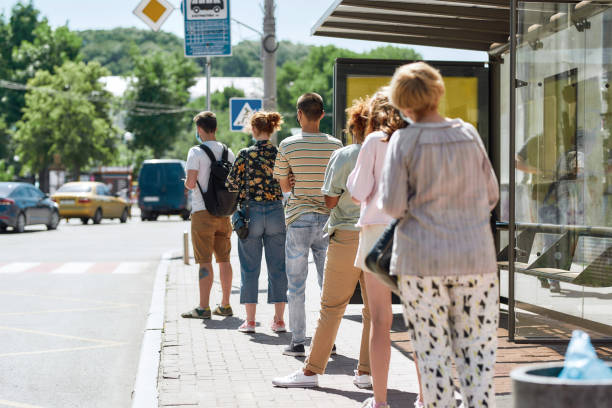


Pregunta al Agente
¿Qué quieres saber sobre la imagen? (ej: ¿Qué ves aquí?): ¿Qué ves aquí?

[Agente Pensando...]

--------------------------------------------------
RESPUESTA DEL AGENTE:
En la imagen 'istockphoto-1307548287-612x612 (1).jpg' se han detectado 3 coches, 5 personas y 1 camión.
--------------------------------------------------

Generando imagen con detecciones...


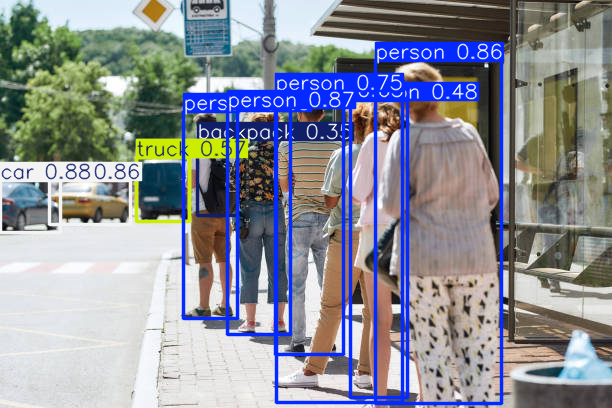

In [7]:
def main():
    print("Sube tu imagen")
    # Función de Colab para subir archivos
    uploaded = files.upload()

    if not uploaded:
        print("No se subió ninguna imagen.")
        return

    # Obtenemos el nombre del archivo subido
    filename = next(iter(uploaded))
    print(f"\nImagen '{filename}' recibida.")

    # Mostramos la imagen para confirmar
    display(Image(filename, width=400))

    print("\nPregunta al Agente")
    pregunta_usuario = input("¿Qué quieres saber sobre la imagen? (ej: ¿Qué ves aquí?): ")

    if not pregunta_usuario:
        pregunta_usuario = "¿Qué objetos hay en esta imagen?"

    # Construimos el prompt. Es CRUCIAL decirle al agente dónde está la imagen (filename) para que sepa qué pasarle a la herramienta 'detectar_objetos'.
    mensaje_sistema = f"El usuario ha subido una imagen llamada '{filename}'. {pregunta_usuario} Usa la herramienta de detección si es necesario."

    print("\n[Agente Pensando...]\n")

    # Ejecutamos el agente
    response = agent_executor.invoke({"messages": [("user", mensaje_sistema)]})

    # Imprimimos la última respuesta del agente
    print("-" * 50)
    print("RESPUESTA DEL AGENTE:")
    print(response["messages"][-1].content)
    print("-" * 50)

    # VISUALIZACIÓN YOLO
    print("\nGenerando imagen con detecciones...")

    # Importamos PIL aquí dentro para evitar conflictos con la otra librería Image
    from PIL import Image as PILImage
    import numpy as np

    # Usamos el modelo YOLO que cargamos al principio
    resultados_visuales = yolo_model(filename)

    # Mostramos la imagen con las cajas verdes
    for r in resultados_visuales:
        # r.plot() devuelve la imagen en formato BGR (OpenCV)
        im_array = r.plot()
        # Convertimos de BGR a RGB para que los colores se vean bien
        im_rgb = im_array[..., ::-1]
        # Creamos una imagen PIL y la mostramos
        display(PILImage.fromarray(im_rgb))

# Ejecutamos la aplicación
if __name__ == "__main__":
    main()